# Fractional-reserve two-sector exchange model

This notebook implements a **simplified statistical-mechanical model inspired by the reserve-ratio model of Xi, Ding, and Wang**. It is not a simulation of banks or a complete model of fractional-reserve banking. By construction, it assigns $N_+=rN$ agents to a nonnegative-money pool and $N_-=(1-r)N$ agents to an independently conserved debt-magnitude pool. The signed balances in the debt sector are $m_i^-=-d_i$.

For a reserve parameter $r$ and monetary base $M_0$, the two conserved aggregates are

$$M_+=\frac{M_0}{r},\qquad M_-=\frac{M_0(1-r)}{r},\qquad M_+-M_-=M_0.$$

Transactions move a fixed amount $\Delta m$ between two distinct agents in one randomly selected sector. A transaction is rejected when the selected donor cannot pay. We test the continuous large-population prediction

$$P(m)=\begin{cases}\frac{r}{T_+}e^{-m/T_+},&m\geq0,\\[3pt]\frac{1-r}{T_-}e^{m/T_-},&m<0,\end{cases}\qquad T_+=\frac{M_0}{r^2N},\quad T_- = \frac{M_0}{rN}.$$

The reserve ratio does not imply the positive-agent fraction: $N_+=rN$ is an additional assumption of this construction. Likewise, $r=(\sqrt5-1)/2$ is tested only as the parameter that makes the two continuous theoretical branches meet at zero, not as a generally correct banking reserve ratio.

Because transfers are discrete, the finite simulation has a lattice-like stationary state; the continuous exponential curves are a large-system approximation. The simulation checks conservation throughout, compares shape separately in each sector, and repeats the $r=0.8$ run from a second strongly out-of-equilibrium state.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


### Numerical transaction scheduler

To avoid a slow interpreted loop over 60 million proposals, the implementation groups events into random-matching rounds. In each sector, a fresh uniform random permutation is paired adjacently; each pair gets a uniformly random donor direction, and an insolvent donor causes a rejected event. Every pair is therefore uniformly sampled marginally, while events within the same round are correlated because no agent is paired twice in that round. The code counts each attempted pair as one transaction and stops at exactly the requested total. This batching changes the event correlations, not the fixed-amount transfer or sector conservation rules.

In [2]:
# Main experiment: change these values to explore another system size or runtime.
N = 500
M0 = 5_000.0
DELTA_M = 1.0
N_TRANSACTIONS = 10_000_000
R_VALUES = [0.2, 0.4, 0.6, 0.618, 0.8, 0.9]
R_GOLDEN = (np.sqrt(5) - 1) / 2
CHECK_INTERVAL = 100_000
BASE_SEED = 20261005
INITIALIZATION = "concentrated"  # Alternative: "two_agents"
RELAXATION_CHECKPOINTS = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]

assert 0 < min(R_VALUES) < max(R_VALUES) < 1
assert N_TRANSACTIONS >= max(RELAXATION_CHECKPOINTS)
print(f"N={N}, M0={M0:g}, transaction amount={DELTA_M:g}, proposals per run={N_TRANSACTIONS:,}")


N=500, M0=5000, transaction amount=1, proposals per run=10,000,000


In [3]:
def model_parameters(r, n_agents=N, monetary_base=M0):
    n_positive = int(round(r * n_agents))
    n_debt = n_agents - n_positive
    if n_positive < 2 or n_debt < 2:
        raise ValueError("Each sector must contain at least two agents.")
    money_positive = monetary_base / r
    debt_total = monetary_base * (1 - r) / r
    return {
        "r": r,
        "n_positive": n_positive,
        "n_debt": n_debt,
        "r_realized": n_positive / n_agents,
        "money_positive": money_positive,
        "debt_total": debt_total,
        "T_positive": money_positive / n_positive,
        "T_debt": debt_total / n_debt,
    }


def theoretical_density(money, r, monetary_base=M0, n_agents=N):
    money = np.asarray(money, dtype=float)
    t_positive = monetary_base / (r**2 * n_agents)
    t_debt = monetary_base / (r * n_agents)
    density = np.empty_like(money)
    positive = money >= 0
    density[positive] = r / t_positive * np.exp(-money[positive] / t_positive)
    density[~positive] = (1 - r) / t_debt * np.exp(money[~positive] / t_debt)
    return density


def theoretical_moments(r, monetary_base=M0, n_agents=N):
    t_positive = monetary_base / (r**2 * n_agents)
    t_debt = monetary_base / (r * n_agents)
    positive_mass = quad(lambda m: r / t_positive * np.exp(-m / t_positive), 0, np.inf)[0]
    debt_mass = quad(lambda m: (1 - r) / t_debt * np.exp(m / t_debt), -np.inf, 0)[0]
    mean = r * t_positive - (1 - r) * t_debt
    return positive_mass, debt_mass, positive_mass + debt_mass, mean


for r in R_VALUES:
    p_plus, p_debt, normalization, mean = theoretical_moments(r)
    assert np.isclose(normalization, 1.0, atol=1e-10)
    assert np.isclose(mean, M0 / N, atol=1e-10)
print("All six theoretical distributions integrate to 1 and have mean M0/N = {:.3f}.".format(M0 / N))


All six theoretical distributions integrate to 1 and have mean M0/N = 10.000.


In [4]:
def initialize_pool(total, n_agents, transaction_amount, method):
    whole_units = int(np.floor(total / transaction_amount + 1e-12))
    remainder = total - whole_units * transaction_amount
    pool = np.zeros(n_agents, dtype=float)

    if method == "concentrated":
        n_active = max(2, n_agents // 10)
        units_per_agent, extra_units = divmod(whole_units, n_active)
        pool[:n_active] = units_per_agent * transaction_amount
        pool[:extra_units] += transaction_amount
        pool[0] += remainder
    elif method == "two_agents":
        if n_agents < 2:
            raise ValueError("The two-agent initialization needs at least two agents.")
        first_units = int(0.75 * whole_units)
        pool[0] = first_units * transaction_amount + remainder
        pool[1] = (whole_units - first_units) * transaction_amount
    else:
        raise ValueError("method must be 'concentrated' or 'two_agents'.")

    if not np.isclose(pool.sum(), total, rtol=0, atol=1e-9 * max(1, total)):
        raise ArithmeticError("Initialization failed to conserve the pool total.")
    return pool


def draw_sector_events(n_agents, sector, rng):
    permutation = rng.permutation(n_agents)
    n_pairs = n_agents // 2
    first = permutation[: 2 * n_pairs : 2]
    second = permutation[1 : 2 * n_pairs : 2]
    first_donates = rng.random(n_pairs) < 0.5
    donors = np.where(first_donates, first, second)
    receivers = np.where(first_donates, second, first)
    sectors = np.full(n_pairs, sector, dtype=np.int8)
    return sectors, donors, receivers


def run_simulation(r, initialization=INITIALIZATION, seed=BASE_SEED,
                   n_transactions=N_TRANSACTIONS, checkpoints=(),
                   check_interval=CHECK_INTERVAL):
    parameters = model_parameters(r)
    positive = initialize_pool(parameters["money_positive"], parameters["n_positive"], DELTA_M, initialization)
    debt = initialize_pool(parameters["debt_total"], parameters["n_debt"], DELTA_M, initialization)
    target_positive = parameters["money_positive"]
    target_debt = parameters["debt_total"]
    rng = np.random.default_rng(seed)
    checkpoints = sorted(set(int(value) for value in checkpoints if 0 < value <= n_transactions))
    snapshots = {}
    checkpoint_index = 0
    completed = 0
    accepted = 0
    max_drift_positive = 0.0
    max_drift_debt = 0.0

    while completed < n_transactions:
        positive_events = draw_sector_events(parameters["n_positive"], 0, rng)
        debt_events = draw_sector_events(parameters["n_debt"], 1, rng)
        sectors = np.concatenate((positive_events[0], debt_events[0]))
        donors = np.concatenate((positive_events[1], debt_events[1]))
        receivers = np.concatenate((positive_events[2], debt_events[2]))
        event_order = rng.permutation(sectors.size)
        sweep_size = min(sectors.size, n_transactions - completed)
        cursor = 0

        while cursor < sweep_size:
            next_boundary = completed + sweep_size
            if checkpoint_index < len(checkpoints):
                next_boundary = min(next_boundary, checkpoints[checkpoint_index])
            next_boundary = min(next_boundary, ((completed // check_interval) + 1) * check_interval)
            count = next_boundary - completed
            selected = event_order[cursor : cursor + count]
            selected_sectors = sectors[selected]

            positive_mask = selected_sectors == 0
            positive_donors = donors[selected[positive_mask]]
            positive_receivers = receivers[selected[positive_mask]]
            positive_can_pay = positive[positive_donors] >= DELTA_M
            positive_donors = positive_donors[positive_can_pay]
            positive_receivers = positive_receivers[positive_can_pay]
            positive[positive_donors] -= DELTA_M
            positive[positive_receivers] += DELTA_M

            debt_mask = selected_sectors == 1
            debt_donors = donors[selected[debt_mask]]
            debt_receivers = receivers[selected[debt_mask]]
            debt_can_pay = debt[debt_donors] >= DELTA_M
            debt_donors = debt_donors[debt_can_pay]
            debt_receivers = debt_receivers[debt_can_pay]
            debt[debt_donors] -= DELTA_M
            debt[debt_receivers] += DELTA_M
            accepted += positive_donors.size + debt_donors.size

            completed = next_boundary
            cursor += count

            if checkpoint_index < len(checkpoints) and completed == checkpoints[checkpoint_index]:
                snapshots[completed] = np.concatenate((positive.copy(), -debt.copy()))
                checkpoint_index += 1

            if completed % check_interval == 0:
                drift_positive = abs(positive.sum() - target_positive)
                drift_debt = abs(debt.sum() - target_debt)
                max_drift_positive = max(max_drift_positive, drift_positive)
                max_drift_debt = max(max_drift_debt, drift_debt)
                if drift_positive > 1e-8 * max(1, target_positive):
                    raise ArithmeticError("Positive-sector money conservation failed.")
                if drift_debt > 1e-8 * max(1, target_debt):
                    raise ArithmeticError("Debt-sector conservation failed.")

    return {
        **parameters,
        "positive": positive,
        "debt": debt,
        "signed_balances": np.concatenate((positive, -debt)),
        "accepted": accepted,
        "acceptance_rate": accepted / n_transactions,
        "snapshots": snapshots,
        "max_drift_positive": max_drift_positive,
        "max_drift_debt": max_drift_debt,
        "initialization": initialization,
        "seed": seed,
        "n_transactions": n_transactions,
    }


In [5]:
# Fast smoke test: exact proposal count, snapshots, and both conservation laws.
smoke_test = run_simulation(
    0.8,
    initialization="concentrated",
    seed=123,
    n_transactions=10_000,
    checkpoints=[100, 1_000, 10_000],
    check_interval=1_000,
)
assert list(smoke_test["snapshots"]) == [100, 1_000, 10_000]
assert np.isclose(smoke_test["positive"].sum(), smoke_test["money_positive"], atol=1e-8)
assert np.isclose(smoke_test["debt"].sum(), smoke_test["debt_total"], atol=1e-8)
print("Smoke test passed: 10,000 proposals, ordered snapshots, and conserved sector totals.")


Smoke test passed: 10,000 proposals, ordered snapshots, and conserved sector totals.


In [6]:
simulation_results = {}

for case_index, r in enumerate(R_VALUES):
    case_checkpoints = RELAXATION_CHECKPOINTS if np.isclose(r, 0.8) else ()
    started = time.perf_counter()
    result = run_simulation(
        r,
        initialization=INITIALIZATION,
        seed=BASE_SEED + case_index,
        checkpoints=case_checkpoints,
    )
    result["runtime_seconds"] = time.perf_counter() - started

    empirical_mean = result["signed_balances"].mean()
    assert np.isclose(result["positive"].sum(), result["money_positive"], rtol=0, atol=1e-7)
    assert np.isclose(result["debt"].sum(), result["debt_total"], rtol=0, atol=1e-7)
    assert np.isclose(empirical_mean, M0 / N, rtol=0, atol=1e-8)
    simulation_results[r] = result
    print(
        f"r={r:.3f}: N+={result['n_positive']}, N-={result['n_debt']}, "
        f"accepted={result['accepted']:,}/{N_TRANSACTIONS:,}, "
        f"time={result['runtime_seconds']:.1f}s"
    )

print("All six runs conserve both pools and the net monetary base.")


r=0.200: N+=100, N-=400, accepted=9,715,005/10,000,000, time=3.8s
r=0.400: N+=200, N-=300, accepted=9,629,476/10,000,000, time=3.8s
r=0.600: N+=300, N-=200, accepted=9,514,716/10,000,000, time=3.7s
r=0.618: N+=309, N-=191, accepted=9,498,385/10,000,000, time=3.4s
r=0.800: N+=400, N-=100, accepted=9,353,846/10,000,000, time=6.4s
r=0.900: N+=450, N-=50, accepted=9,230,178/10,000,000, time=4.0s
All six runs conserve both pools and the net monetary base.


In [7]:
def ks_statistic_against_exponential(sample, scale):
    values = np.sort(np.asarray(sample, dtype=float))
    n = values.size
    theoretical_cdf = 1 - np.exp(-values / scale)
    ranks = np.arange(1, n + 1) / n
    d_plus = np.max(ranks - theoretical_cdf)
    d_minus = np.max(theoretical_cdf - (ranks - 1 / n))
    return max(d_plus, d_minus)


summary_rows = []
for r, result in simulation_results.items():
    positive = result["positive"]
    debt = result["debt"]
    t_positive = result["T_positive"]
    t_debt = result["T_debt"]
    summary_rows.append({
        "r": r,
        "N+": result["n_positive"],
        "N-": result["n_debt"],
        "M+ sim": positive.sum(),
        "M+ theory": result["money_positive"],
        "M- sim": debt.sum(),
        "M- theory": result["debt_total"],
        "mean m": result["signed_balances"].mean(),
        "mean |m|+": positive.mean(),
        "T+ theory": t_positive,
        "mean |m|-": debt.mean(),
        "T- theory": t_debt,
        "KS+": ks_statistic_against_exponential(positive, t_positive),
        "KS-": ks_statistic_against_exponential(debt, t_debt),
        "acceptance": result["acceptance_rate"],
    })

print("r    N+/N-       M+ sim/theory       M- sim/theory       mean m   theory   T+ sim/theory   T- sim/theory   KS+/KS-")
for row in summary_rows:
    result = simulation_results[row["r"]]
    print(
        f"{row['r']:.3f} {row['N+']:3d}/{row['N-']:<3d} "
        f"{row['M+ sim']:8.2f}/{row['M+ theory']:8.2f} "
        f"{row['M- sim']:8.2f}/{row['M- theory']:8.2f} "
        f"{row['mean m']:7.3f}/{M0 / N:7.3f} "
        f"{row['mean |m|+']:7.3f}/{row['T+ theory']:7.3f} "
        f"{row['mean |m|-']:7.3f}/{row['T- theory']:7.3f} "
        f"{row['KS+']:.3f}/{row['KS-']:.3f}"
    )
    assert np.isclose(result["positive"].sum(), result["money_positive"], atol=1e-7)
    assert np.isclose(result["debt"].sum(), result["debt_total"], atol=1e-7)
    assert np.isclose(result["signed_balances"].mean(), M0 / N, atol=1e-8)

print("\nKS values are shape diagnostics against the theoretical exponential scales; no p-values are reported.")


r    N+/N-       M+ sim/theory       M- sim/theory       mean m   theory   T+ sim/theory   T- sim/theory   KS+/KS-
0.200 100/400 25000.00/25000.00 20000.00/20000.00  10.000/ 10.000 250.000/250.000  50.000/ 50.000 0.461/0.033
0.400 200/300 12500.00/12500.00  7500.00/ 7500.00  10.000/ 10.000  62.500/ 62.500  25.000/ 25.000 0.043/0.064
0.600 300/200  8333.33/ 8333.33  3333.33/ 3333.33  10.000/ 10.000  27.778/ 27.778  16.667/ 16.667 0.044/0.062
0.618 309/191  8090.61/ 8090.61  3090.61/ 3090.61  10.000/ 10.000  26.183/ 26.183  16.181/ 16.181 0.044/0.085
0.800 400/100  6250.00/ 6250.00  1250.00/ 1250.00  10.000/ 10.000  15.625/ 15.625  12.500/ 12.500 0.088/0.090
0.900 450/50   5555.56/ 5555.56   555.56/  555.56  10.000/ 10.000  12.346/ 12.346  11.111/ 11.111 0.076/0.078

KS values are shape diagnostics against the theoretical exponential scales; no p-values are reported.


In [8]:
low_r_positive = simulation_results[0.2]["positive"]
print("r=0.2 positive balance quantiles:", np.quantile(low_r_positive, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 1]))
print("Zero-balance agents:", np.count_nonzero(low_r_positive == 0), "of", low_r_positive.size)


r=0.2 positive balance quantiles: [   0.      5.8    20.75   48.     90.    365.7  2130.15 2343.  ]
Zero-balance agents: 3 of 100


In [9]:
# The r=0.2 positive branch is the slowest to relax from the chosen initialization.
# Extend this case to test convergence beyond the required 10-million-proposal run.
LOW_R_EXTENDED_TRANSACTIONS = 50_000_000
started = time.perf_counter()
low_r_extended = run_simulation(
    0.2,
    initialization=INITIALIZATION,
    seed=BASE_SEED,
    n_transactions=LOW_R_EXTENDED_TRANSACTIONS,
    checkpoints=[10_000_000, 25_000_000, LOW_R_EXTENDED_TRANSACTIONS],
)
print(f"Extended r=0.2 run completed in {time.perf_counter() - started:.1f}s.")

for transaction_count, signed_state in low_r_extended["snapshots"].items():
    positive_state = signed_state[: low_r_extended["n_positive"]]
    debt_state = -signed_state[low_r_extended["n_positive"] :]
    print(
        f"{transaction_count:>10,} proposals: "
        f"KS+={ks_statistic_against_exponential(positive_state, low_r_extended['T_positive']):.3f}, "
        f"KS-={ks_statistic_against_exponential(debt_state, low_r_extended['T_debt']):.3f}"
    )


Extended r=0.2 run completed in 16.9s.
10,000,000 proposals: KS+=0.461, KS-=0.033
25,000,000 proposals: KS+=0.233, KS-=0.049
50,000,000 proposals: KS+=0.164, KS-=0.053


In [10]:
from scipy.stats import ks_2samp

started = time.perf_counter()
reference_two_agent_start = run_simulation(
    0.8,
    initialization="two_agents",
    seed=BASE_SEED + R_VALUES.index(0.8),
    n_transactions=N_TRANSACTIONS,
)
print(f"Second r=0.8 initialization completed in {time.perf_counter() - started:.1f}s.")

reference_concentrated = simulation_results[0.8]
for sector_name, first, second in (
    ("positive", reference_concentrated["positive"], reference_two_agent_start["positive"]),
    ("debt magnitude", reference_concentrated["debt"], reference_two_agent_start["debt"]),
):
    print(
        f"{sector_name:>14}: KS to exponential "
        f"{ks_statistic_against_exponential(first, reference_concentrated['T_positive' if sector_name == 'positive' else 'T_debt']):.3f} vs "
        f"{ks_statistic_against_exponential(second, reference_two_agent_start['T_positive' if sector_name == 'positive' else 'T_debt']):.3f}; "
        f"two-sample KS={ks_2samp(first, second).statistic:.3f}"
    )


Second r=0.8 initialization completed in 3.6s.
      positive: KS to exponential 0.088 vs 0.150; two-sample KS=0.172
debt magnitude: KS to exponential 0.090 vs 0.073; two-sample KS=0.070


### Continuity at zero is a special parameter choice

For the continuous theory, the branch heights at the origin are $P_+(0)=r/T_+$ and $P_-(0)=(1-r)/T_-$. Their equality occurs at $r=(\sqrt5-1)/2$. This is a continuity condition on this simplified distribution, not a banking identity. The simulated reference case remains $r=0.8$.

In [11]:
def branch_heights_at_zero(r, monetary_base=M0, n_agents=N):
    t_positive = monetary_base / (r**2 * n_agents)
    t_debt = monetary_base / (r * n_agents)
    return r / t_positive, (1 - r) / t_debt


for r in (R_GOLDEN, 0.8):
    height_positive, height_debt = branch_heights_at_zero(r)
    print(
        f"r={r:.6f}: P+(0)={height_positive:.6f}, "
        f"P-(0)={height_debt:.6f}, difference={height_positive - height_debt:+.6f}"
    )

golden_heights = branch_heights_at_zero(R_GOLDEN)
reference_heights = branch_heights_at_zero(0.8)
assert np.isclose(golden_heights[0], golden_heights[1], rtol=1e-12)
assert not np.isclose(reference_heights[0], reference_heights[1], rtol=1e-3)


r=0.618034: P+(0)=0.023607, P-(0)=0.023607, difference=+0.000000
r=0.800000: P+(0)=0.051200, P-(0)=0.016000, difference=+0.035200


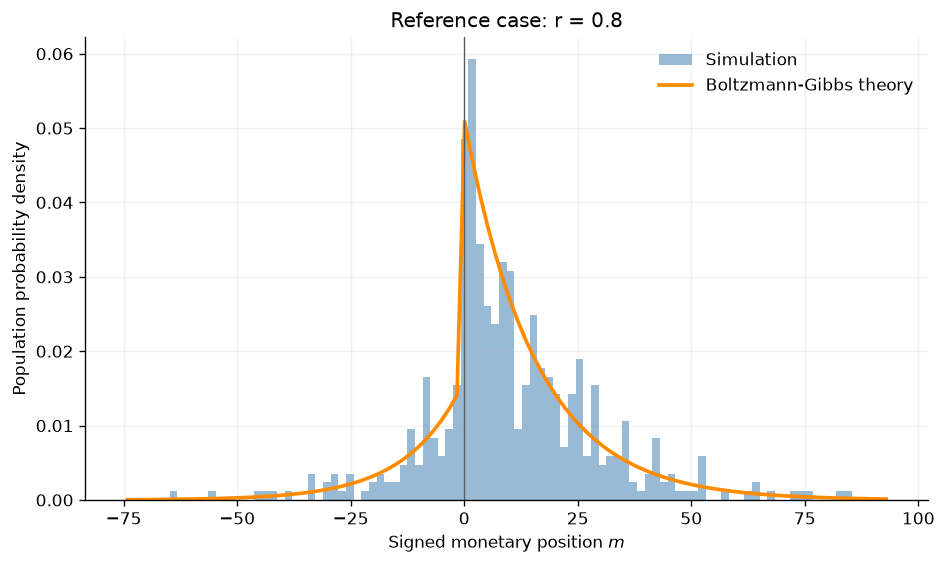

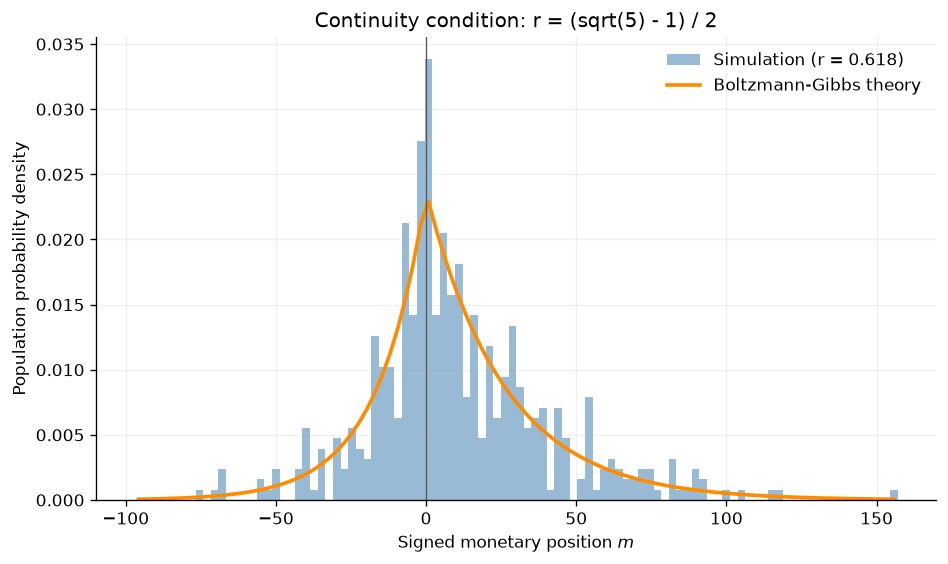

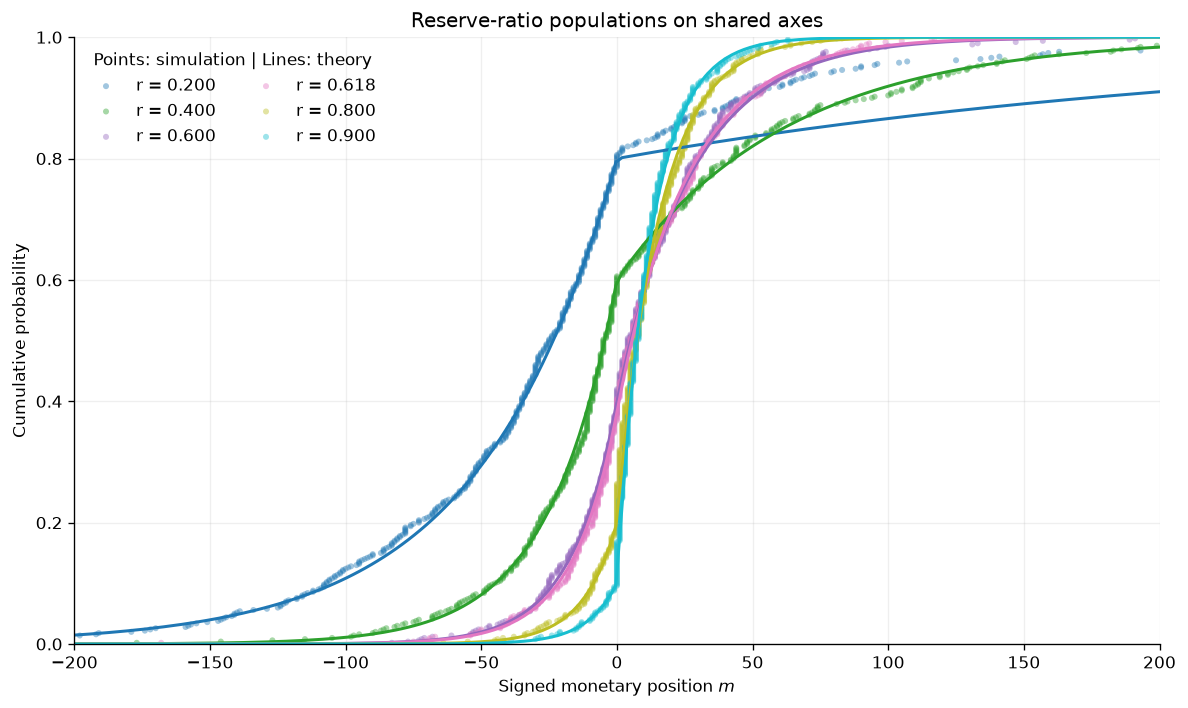

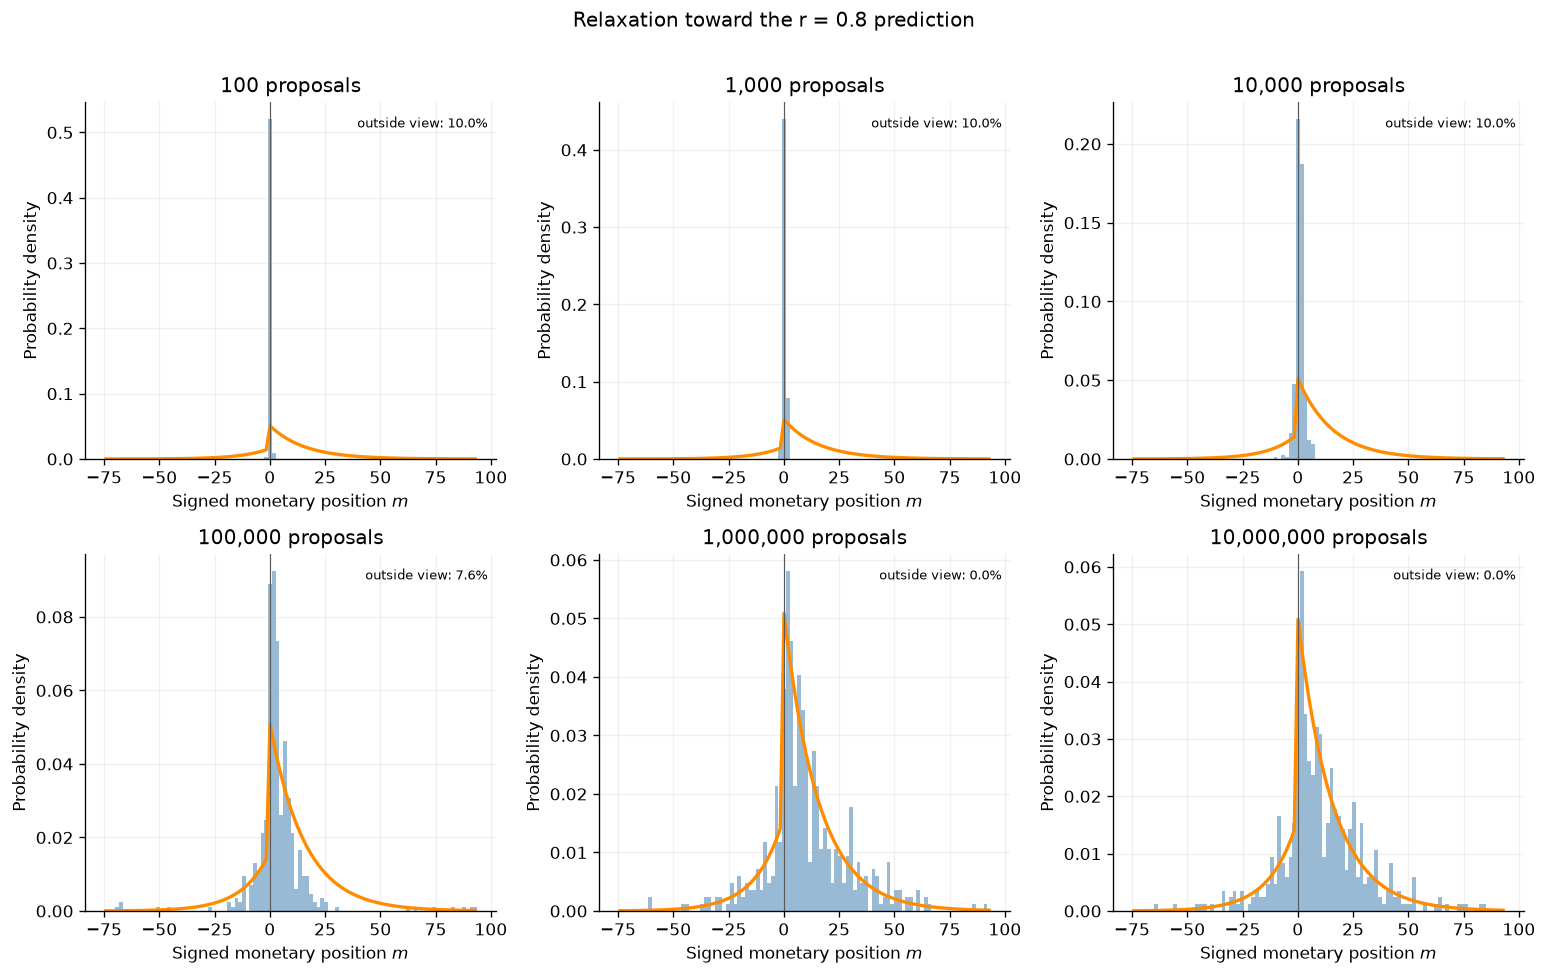

In [12]:
def comparison_bin_edges(r, n_bins=100, tail_scales=6):
    t_positive = M0 / (r**2 * N)
    t_debt = M0 / (r * N)
    return np.linspace(-tail_scales * t_debt, tail_scales * t_positive, n_bins + 1)


def plot_distribution_comparison(ax, balances, r_theory, label="Simulation"):
    edges = comparison_bin_edges(r_theory)
    width = edges[1] - edges[0]
    weights = np.full(balances.size, 1 / (N * width))
    ax.hist(balances, bins=edges, weights=weights, color="steelblue", alpha=0.55, label=label)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.plot(centers, theoretical_density(centers, r_theory), color="darkorange", linewidth=2.2, label="Boltzmann-Gibbs theory")
    ax.axvline(0, color="0.35", linewidth=0.8)
    ax.set(xlabel="Signed monetary position $m$", ylabel="Population probability density")
    ax.grid(alpha=0.18)
    return edges


def theoretical_cdf(money, r):
    money = np.asarray(money, dtype=float)
    t_positive = M0 / (r**2 * N)
    t_debt = M0 / (r * N)
    cdf = np.empty_like(money)
    negative = money < 0
    cdf[negative] = (1 - r) * np.exp(money[negative] / t_debt)
    cdf[~negative] = 1 - r * np.exp(-money[~negative] / t_positive)
    return cdf


# Figure 1: literature-reference reserve parameter.
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_distribution_comparison(ax, simulation_results[0.8]["signed_balances"], 0.8)
ax.set_title("Reference case: r = 0.8")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Figure 2: simulate r=0.618 and overlay the exact golden-ratio continuity curve.
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_distribution_comparison(ax, simulation_results[0.618]["signed_balances"], R_GOLDEN, label="Simulation (r = 0.618)")
ax.set_title("Continuity condition: r = (sqrt(5) - 1) / 2")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Figure 3: all six simulated populations as points on shared empirical-CDF axes.
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.colormaps["tab10"](np.linspace(0, 1, len(R_VALUES)))
max_t_positive = max(M0 / (r**2 * N) for r in R_VALUES)
max_t_debt = max(M0 / (r * N) for r in R_VALUES)
x_grid = np.linspace(-6 * max_t_debt, 6 * max_t_positive, 800)

for color, r in zip(colors, R_VALUES):
    balances = np.sort(simulation_results[r]["signed_balances"])
    empirical_cdf = np.arange(1, balances.size + 1) / balances.size
    ax.scatter(balances, empirical_cdf, s=13, alpha=0.42, color=color, edgecolors="none", label=f"r = {r:.3f}")
    ax.plot(x_grid, theoretical_cdf(x_grid, r), color=color, linewidth=1.8)

ax.set(
    xlim=(-200, 200),
    ylim=(0, 1),
    xlabel="Signed monetary position $m$",
    ylabel="Cumulative probability",
    title="Reserve-ratio populations on shared axes",
)
ax.legend(title="Points: simulation | Lines: theory", frameon=False, ncol=2)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

# Figure 4: relaxation from the concentrated initial condition for r=0.8.
relaxation_result = simulation_results[0.8]
relaxation_snapshots = relaxation_result["snapshots"]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, transaction_count in zip(axes.flat, RELAXATION_CHECKPOINTS):
    balances = relaxation_snapshots[transaction_count]
    edges = comparison_bin_edges(0.8)
    width = edges[1] - edges[0]
    weights = np.full(balances.size, 1 / (N * width))
    ax.hist(balances, bins=edges, weights=weights, color="steelblue", alpha=0.55)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.plot(centers, theoretical_density(centers, 0.8), color="darkorange", linewidth=2)
    visible_fraction = np.mean((balances >= edges[0]) & (balances <= edges[-1]))
    ax.set_title(f"{transaction_count:,} proposals")
    ax.text(0.98, 0.96, f"outside view: {1 - visible_fraction:.1%}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8)
    ax.axvline(0, color="0.35", linewidth=0.7)
    ax.set(xlabel="Signed monetary position $m$", ylabel="Probability density")
    ax.grid(alpha=0.18)
fig.suptitle("Relaxation toward the r = 0.8 prediction", y=1.01)
fig.tight_layout()
plt.show()


In [13]:
print("Maximum absolute sector-total drift observed at 100,000-proposal checks:")
for r, result in simulation_results.items():
    print(f"r={r:.3f}: positive={result['max_drift_positive']:.3e}, debt={result['max_drift_debt']:.3e}")

for label, result in (("r=0.2 extended", low_r_extended), ("r=0.8 two-agent start", reference_two_agent_start)):
    positive_drift = abs(result["positive"].sum() - result["money_positive"])
    debt_drift = abs(result["debt"].sum() - result["debt_total"])
    assert positive_drift < 1e-7 and debt_drift < 1e-7
    print(f"{label}: final positive drift={positive_drift:.3e}, debt drift={debt_drift:.3e}")


Maximum absolute sector-total drift observed at 100,000-proposal checks:
r=0.200: positive=0.000e+00, debt=0.000e+00
r=0.400: positive=0.000e+00, debt=0.000e+00
r=0.600: positive=0.000e+00, debt=0.000e+00
r=0.618: positive=0.000e+00, debt=0.000e+00
r=0.800: positive=0.000e+00, debt=0.000e+00
r=0.900: positive=0.000e+00, debt=0.000e+00
r=0.2 extended: final positive drift=0.000e+00, debt drift=0.000e+00
r=0.8 two-agent start: final positive drift=0.000e+00, debt drift=0.000e+00


### Interpretation and limitations

The standard concentrated start assigns each pool equally to 10% of its agents and leaves the rest at zero; the alternate start places 75% on one agent and the remainder on a second. The positive and debt totals are conserved exactly, and therefore the empirical net mean is fixed at $M_0/N=10$. The sector sample means likewise equal their theoretical scales by construction; these checks validate bookkeeping, not the exponential shape. The branch-wise KS statistics are the shape diagnostics. The $r=0.2$ positive branch relaxes slowly: its KS statistic falls from 0.461 at $10^7$ proposals to 0.164 at $5\times10^7$, while its debt branch is already close to the exponential prediction.

For $r=0.8$, the two different starts give two-sample KS statistics of 0.172 (positive balances) and 0.070 (debt magnitudes) after $10^7$ proposals. This tests sensitivity to the initial state but does not establish exact independence at finite time. The fixed transaction size also creates a discrete finite-system stationary distribution, whereas the overlaid exponentials are its continuous statistical-mechanical approximation. Finally, random-matching rounds make pair choices uniform marginally but correlated within each round for computational efficiency. These results concern the stated two-pool abstraction only, not a complete fractional-reserve banking system.